In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("image.jpeg", cv2.IMREAD_GRAYSCALE)

In [2]:
# Convert to binary image
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

In [3]:
# 3 x 3 structuring element
kernel = np.ones((3, 3), dtype=np.uint8)

In [4]:
# =================================
# Erosion
# =================================

def erosion(image, kernel):
    result = np.zeros_like(image)

    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):

            region = image[i-1:i+2, j-1:j+2]

            if np.all(region[kernel == 1] == 255):
                result[i, j] = 255
            else:
                result[i, j] = 0

    return result

In [5]:
# =================================
# Dilation
# =================================

def dilation(image, kernel):
    result = np.zeros_like(image)

    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):

            region = image[i-1:i+2, j-1:j+2]

            if np.any(region[kernel == 1] == 255):
                result[i, j] = 255
            else:
                result[i, j] = 0

    return result

In [6]:
# =================================
# Apply Erosion
# =================================

eroded = erosion(binary, kernel)

In [7]:
# =================================
# Apply Dilation
# =================================

dilated = dilation(binary, kernel)

In [8]:
# =================================
# Opening
# Erosion followed by Dilation
# =================================

opened = dilation(eroded, kernel)

In [9]:

# =================================
# Closing
# Dilation followed by Erosion
# =================================

closed = erosion(dilated, kernel)

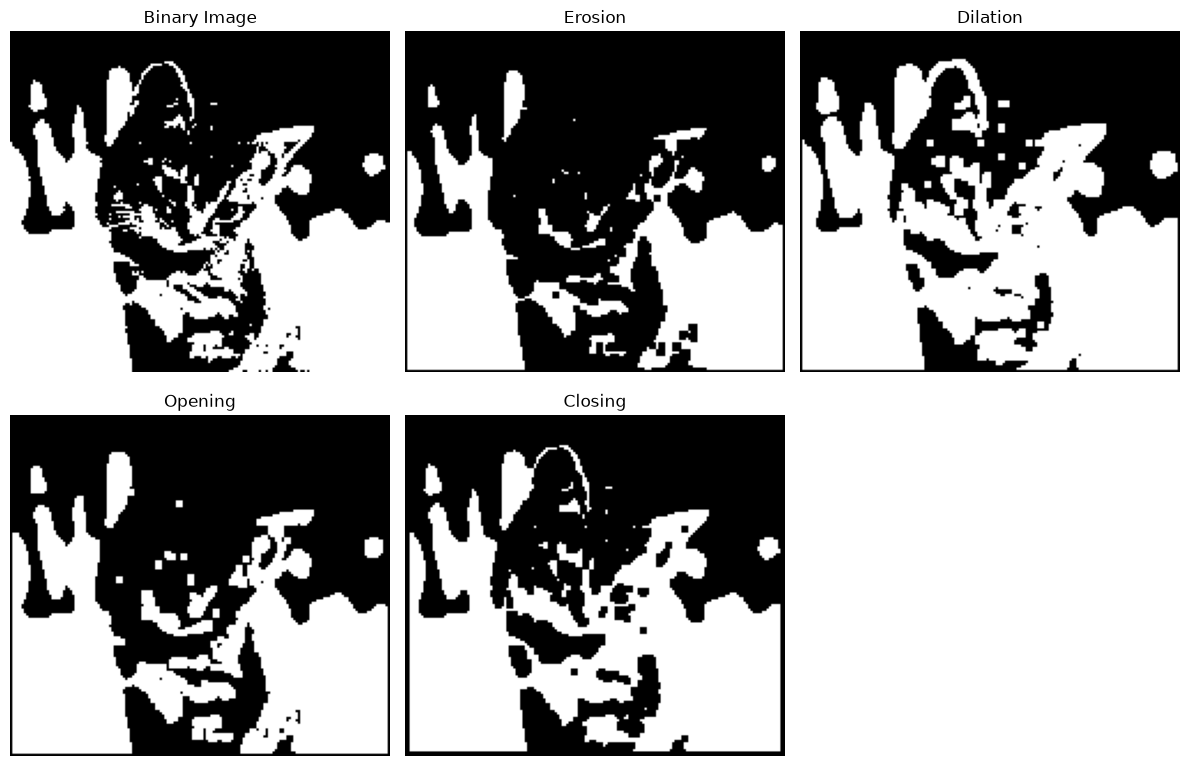

In [10]:
# =================================
# Display Results
# =================================

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(eroded, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(dilated, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(opened, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(closed, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()